**Load data**

In [2]:
import pandas as pd

df = pd.read_csv("/content/data_for_predictions.csv")

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 64 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Unnamed: 0                                  14606 non-null  int64  
 1   id                                          14606 non-null  object 
 2   cons_12m                                    14606 non-null  float64
 3   cons_gas_12m                                14606 non-null  float64
 4   cons_last_month                             14606 non-null  float64
 5   forecast_cons_12m                           14606 non-null  float64
 6   forecast_discount_energy                    14606 non-null  float64
 7   forecast_meter_rent_12m                     14606 non-null  float64
 8   forecast_price_energy_off_peak              14606 non-null  float64
 9   forecast_price_energy_peak                  14606 non-null  float64
 10  forecast_p

In [4]:
print(df.head())

   Unnamed: 0                                id  cons_12m  cons_gas_12m  \
0           0  24011ae4ebbe3035111d65fa7c15bc57  0.000000      4.739944   
1           1  d29c2c54acc38ff3c0614d0a653813dd  3.668479      0.000000   
2           2  764c75f661154dac3a6c254cd082ea7d  2.736397      0.000000   
3           3  bba03439a292a1e166f80264c16191cb  3.200029      0.000000   
4           4  149d57cf92fc41cf94415803a877cb4b  3.646011      0.000000   

   cons_last_month  forecast_cons_12m  forecast_discount_energy  \
0         0.000000           0.000000                       0.0   
1         0.000000           2.280920                       0.0   
2         0.000000           1.689841                       0.0   
3         0.000000           2.382089                       0.0   
4         2.721811           2.650065                       0.0   

   forecast_meter_rent_12m  forecast_price_energy_off_peak  \
0                 0.444045                        0.114481   
1                 1.23

**Prepare features and target**

In [5]:
# Drop 'id' and 'churn' from features
X = df.drop(['churn', 'id'], axis=1)
y = df['churn']

**Train/test split**

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**Train Random Forest**

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Evaluate**

In [8]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

[[2633    5]
 [ 262   22]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      2638
           1       0.81      0.08      0.14       284

    accuracy                           0.91      2922
   macro avg       0.86      0.54      0.55      2922
weighted avg       0.90      0.91      0.87      2922

ROC-AUC Score: 0.6920075227711988


**Feature importance**

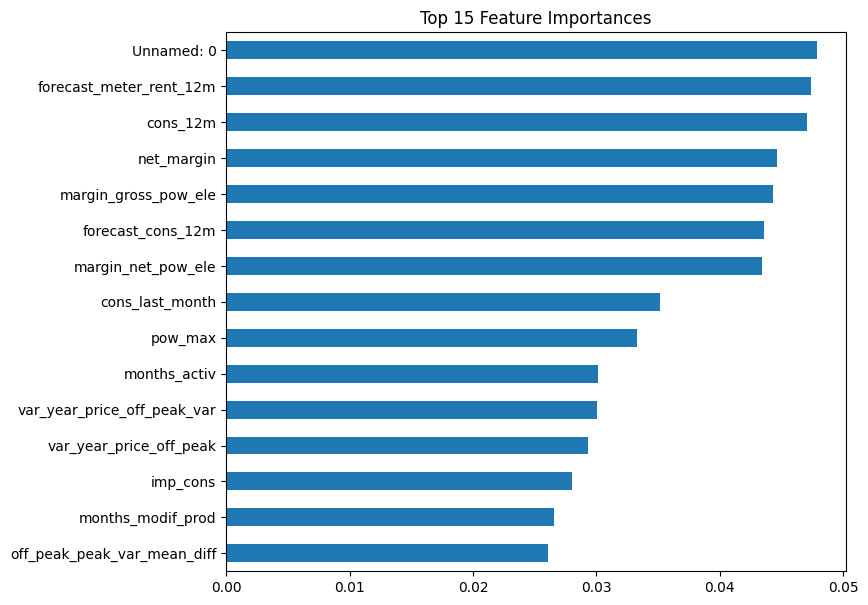

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(15).sort_values().plot(kind='barh', figsize=(8, 7))
plt.title("Top 15 Feature Importances")
plt.show()

**Save predictions**

In [10]:
df_test = X_test.copy()
df_test['actual_churn'] = y_test
df_test['predicted_churn'] = y_pred
df_test['churn_probability'] = y_proba

df_test.to_csv("predictions_output.csv", index=False)
print("✅ Test set predictions saved as 'predictions_output.csv'")


✅ Test set predictions saved as 'predictions_output.csv'
